# Keras, softmax, and what depth costs

Notebook 01 wrote a network by hand, which is the only way to know what
backpropagation actually does. Nobody writes the next one by hand. This
notebook rebuilds the same network in Keras to show they agree, then uses the
library to reach two things NumPy would have made tedious: more than two
classes, and enough depth for the trouble to start.

The trouble is specific and measurable. A sigmoid layer divides the gradient
that reaches it by about four, so a stack of them starves its own first
layers. That single fact explains why the rectified linear unit (ReLU)
replaced the sigmoid in hidden layers, and it is the reason deep networks
were hard to train for twenty years.

Handout sections 6, 7 and 8.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1 tensorflow-cpu==2.21.0

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"     # keep TensorFlow's C++ log quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
import keras
from keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from instrument_data import (make_acceptance_test, load_digit_images,
                             TRUE_N_CLASSES, TRUE_RIG_ERROR_RATE)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD, PLUM = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227", "#7B4B94"

# Two independent settings are needed for a reproducible run: the seed fixes
# the initial weights and the shuffling, and op determinism fixes the order
# in which floating-point reductions happen on multiple threads. Without the
# second, two runs with the same seed still differ in the last decimals.
tf.config.experimental.enable_op_determinism()

print("tensorflow", tf.__version__, " keras", keras.__version__)

I0000 00:00:1787308989.684232 2595594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787308990.809389 2595594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


tensorflow 2.21.0  keras 3.15.1


## 2. The same network, in six lines

Notebook 01's network on the acceptance data: two inputs, four ReLU units,
one sigmoid output, trained by mini-batch gradient descent. Everything the
`forward` and `backward` functions did is now `Dense` and `fit`.

In [2]:
units = make_acceptance_test()
X = units[["gain_offset_db", "phase_offset_deg"]].values
y = units["accepted"].values
truth = units["truly_within_tolerance"].values

X_tr, X_te, y_tr, y_te, t_tr, t_te = train_test_split(
    X, y, truth, test_size=0.25, stratify=y, random_state=9101)
scaler = StandardScaler().fit(X_tr)
Z_tr, Z_te = scaler.transform(X_tr), scaler.transform(X_te)


def acceptance_model(seed):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(4, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


scores = []
for seed in range(3):
    model = acceptance_model(seed)
    model.fit(Z_tr, y_tr, epochs=300, batch_size=64, verbose=0)
    scores.append(model.evaluate(Z_te, y_te, verbose=0)[1])

print(f"Keras, 4 hidden units: {np.mean(scores):.4f} "
      f"(runs: {', '.join(f'{s:.4f}' for s in scores)})")
print(f"notebook 01's NumPy version reached 0.9379 on average, and 0.9307")
print(f"for the single fit it showed. The ceiling is "
      f"{1 - TRUE_RIG_ERROR_RATE:.2f} either way.")
model.summary()

Keras, 4 hidden units: 0.9333 (runs: 0.9467, 0.9293, 0.9240)
notebook 01's NumPy version reached 0.9379 on average, and 0.9307
for the single fit it showed. The ceiling is 0.97 either way.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Same architecture, same optimiser, same result to within the spread across
seeds — and the trainable parameter count in the summary, 17, is exactly what
notebook 01 counted: $2 \times 4$ weights and 4 biases in the hidden layer,
$4 \times 1$ and 1 in the output.

That is the last time this course checks the library against a hand-written
version. From here on the reason to know what `Dense` does is not distrust —
it is that when training fails, the failure is almost always in something the
library hides.

## 3. More than two classes

Everything so far has had one output unit and two classes. The digits data
has ten, and needs the generalisation of the sigmoid: **softmax**.

$$\mathrm{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Ten output units produce ten scores; softmax turns them into a probability
distribution — positive, summing to one. The loss that pairs with it is
categorical cross-entropy, $-\log \hat{y}_{c}$ for the true class $c$, and
handout section 6 shows the same collapse the sigmoid gave: the gradient at
the output is $\hat{y} - y$ with $y$ one-hot.

The data is the 8×8 handwritten digit set that ships inside scikit-learn —
1,797 images, ten classes, no download.

In [3]:
Xd_tr, yd_tr, Xd_va, yd_va, Xd_te, yd_te = load_digit_images()
print(f"train {Xd_tr.shape}   validation {Xd_va.shape}   test {Xd_te.shape}")
print(f"pixels run {Xd_tr.min():.1f} to {Xd_tr.max():.1f} after scaling by 16")
print(f"class counts in training: {np.bincount(yd_tr)}")
print(f"one validation example is worth {100 / len(Xd_va):.3f} percentage points")

train (1077, 64)   validation (360, 64)   test (360, 64)
pixels run 0.0 to 1.0 after scaling by 16
class counts in training: [107 109 106 109 109 109 109 107 104 108]
one validation example is worth 0.278 percentage points


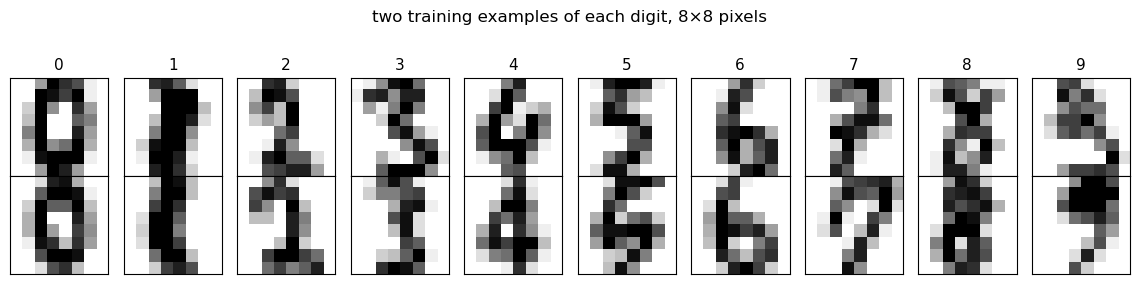

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(11.5, 2.7))
for k in range(TRUE_N_CLASSES):
    for row, index in enumerate(np.where(yd_tr == k)[0][:2]):
        ax = axes[row, k]
        ax.imshow(Xd_tr[index].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(str(k), fontsize=11)
fig.suptitle("two training examples of each digit, 8×8 pixels", y=1.04)
fig.tight_layout()
fig.savefig(FIGURES / "digit_examples.png", dpi=150, bbox_inches="tight")
plt.show()

Eight by eight is small enough that some of these are genuinely ambiguous to
a person. That matters when reading the scores below: this dataset has its
own ceiling, and unlike the acceptance data nobody has published what it is.

In [5]:
def digit_model(hidden, seed=0, activation="relu", dropout=0.0,
                learning_rate=1e-3):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([keras.Input(shape=(64,))])
    for width in hidden:
        model.add(layers.Dense(width, activation=activation))
        if dropout:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(TRUE_N_CLASSES, activation="softmax"))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


rows = []
for name, hidden in (("softmax alone — no hidden layer", []),
                     ("one hidden layer of 32", [32]),
                     ("one hidden layer of 64", [64]),
                     ("two hidden layers of 64", [64, 64])):
    accs = []
    for seed in range(3):
        model = digit_model(hidden, seed=seed)
        model.fit(Xd_tr, yd_tr, epochs=60, batch_size=32, verbose=0)
        accs.append(model.evaluate(Xd_va, yd_va, verbose=0)[1])
    rows.append({"architecture": name, "parameters": model.count_params(),
                 "validation accuracy": np.mean(accs), "sd": np.std(accs)})
pd.DataFrame(rows).set_index("architecture").round(4)

,parameters,validation accuracy,sd
architecture,,,
softmax alone — no hidden layer,650,0.9324,0.0035
one hidden layer of 32,2410,0.9602,0.0052
one hidden layer of 64,4810,0.9611,0.0045
two hidden layers of 64,8970,0.9676,0.0057


Read this next to the acceptance problem, where a linear model scored 0.55
against a network's 0.94. Here softmax with **no hidden layer at all** — which
is multiclass logistic regression, nothing more — is already within three
points of the best network on the table.

That is not a disappointment, it is information. Handwritten digits are close
to linearly separable in pixel space: the classes differ in which pixels are
dark, and a weighted sum of pixels captures most of that. The first hidden
layer is worth about three points. Doubling it from 32 units to 64 is worth
about one tenth of a point — a fifth of the seed-to-seed spread in the last
column, which is to say nothing at all.

**A hidden layer is not free and is not always the answer.** It is the answer
when the thing you are predicting depends on inputs *in combination* — the
acceptance region needed both offsets at once — and much less so when the
inputs already vote fairly independently.

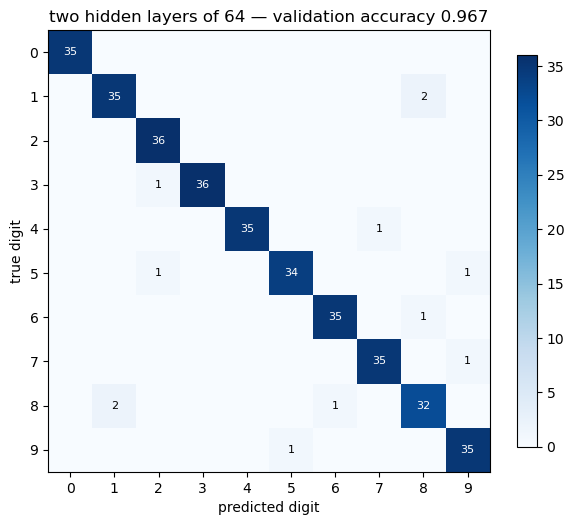

  a 1 was called a 8 2 times
  a 8 was called a 1 2 times
  a 5 was called a 2 1 time


In [6]:
best = digit_model([64, 64], seed=0)
best.fit(Xd_tr, yd_tr, epochs=60, batch_size=32, verbose=0)
predicted = best.predict(Xd_va, verbose=0).argmax(axis=1)
matrix = confusion_matrix(yd_va, predicted)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
image = ax.imshow(matrix, cmap="Blues")
for i in range(TRUE_N_CLASSES):
    for j in range(TRUE_N_CLASSES):
        if matrix[i, j]:
            ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=8,
                    color="white" if matrix[i, j] > matrix.max() * .6 else "black")
ax.set_xticks(range(TRUE_N_CLASSES))
ax.set_yticks(range(TRUE_N_CLASSES))
ax.set_xlabel("predicted digit")
ax.set_ylabel("true digit")
ax.set_title(f"two hidden layers of 64 — validation accuracy "
             f"{(predicted == yd_va).mean():.3f}")
fig.colorbar(image, ax=ax, shrink=.82)
fig.tight_layout()
fig.savefig(FIGURES / "softmax_confusion.png", dpi=150)
plt.show()

off_diagonal = matrix - np.diag(np.diag(matrix))
worst = np.dstack(np.unravel_index(np.argsort(-off_diagonal, axis=None),
                                   off_diagonal.shape))[0][:3]
for i, j in worst:
    count = off_diagonal[i, j]
    print(f"  a {i} was called a {j} {count} time{'s' if count != 1 else ''}")

## 4. Three activation functions

The hidden layer needs *some* non-linearity — stack two linear layers and the
composition is still linear, so the network collapses to one layer and buys
nothing. Which non-linearity is the question this section answers by
measurement rather than by preference.

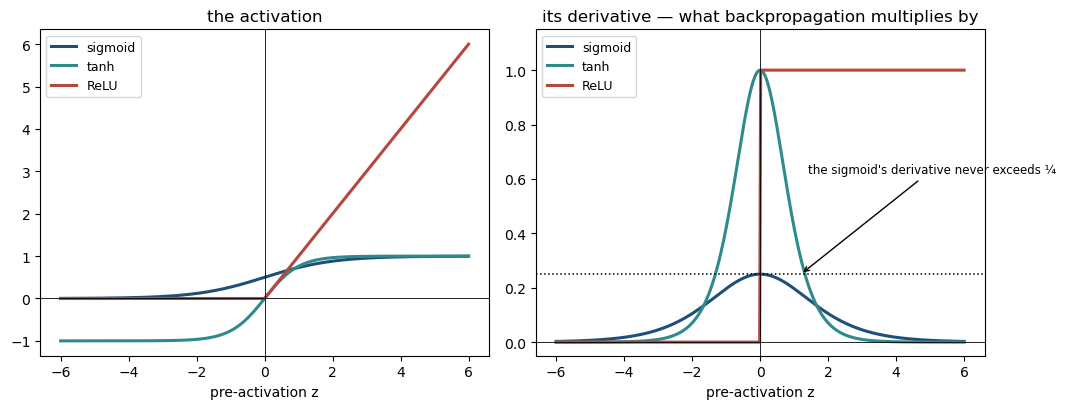

max of the sigmoid's derivative: 0.2500  (exactly 1/4, at z = 0)
max of tanh's derivative       : 0.9998


In [7]:
z = np.linspace(-6, 6, 400)
functions = {
    "sigmoid": (1 / (1 + np.exp(-z)), np.exp(-z) / (1 + np.exp(-z)) ** 2, BLUE),
    "tanh": (np.tanh(z), 1 - np.tanh(z) ** 2, TEAL),
    "ReLU": (np.maximum(0, z), (z > 0).astype(float), RUST),
}

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
for name, (value, slope, colour) in functions.items():
    axes[0].plot(z, value, color=colour, lw=2.2, label=name)
    axes[1].plot(z, slope, color=colour, lw=2.2, label=name)
axes[1].axhline(0.25, color="k", lw=1.1, ls=":")
axes[1].annotate("the sigmoid's derivative never exceeds ¼",
                 xy=(1.2, 0.25), xytext=(1.4, 0.62), fontsize=8.5,
                 arrowprops=dict(arrowstyle="->", lw=1.0))
axes[0].set_title("the activation")
axes[1].set_title("its derivative — what backpropagation multiplies by")
for ax in axes:
    ax.set_xlabel("pre-activation z")
    ax.legend(fontsize=9)
    ax.axhline(0, color="k", lw=.6)
    ax.axvline(0, color="k", lw=.6)
axes[1].set_ylim(-0.05, 1.15)
fig.tight_layout()
fig.savefig(FIGURES / "activation_functions.png", dpi=150)
plt.show()

print(f"max of the sigmoid's derivative: {(np.exp(-z) / (1 + np.exp(-z)) ** 2).max():.4f}"
      f"  (exactly 1/4, at z = 0)")
print(f"max of tanh's derivative       : {(1 - np.tanh(z) ** 2).max():.4f}")

The right-hand panel is the whole story of this notebook. Backpropagation
multiplies by the activation's derivative once per layer on the way back. The
sigmoid's derivative is $\sigma(z)(1 - \sigma(z))$, which peaks at $z = 0$
with value exactly $\tfrac{1}{4}$ and falls away fast in both directions.

Two factors act on the gradient at each layer: the activation's derivative,
and the weight matrix. Initialisation is chosen to make the second about 1
(section 7 derives why), which leaves the first in charge. So a sigmoid layer
multiplies the gradient by **at most ¼**.

At initialisation it is close to that worst case rather than comfortably
inside it: the pre-activations sit near zero, which is precisely where
$\sigma'$ takes its maximum. So the shrinkage per layer should measure close
to 4, scattered a little either side of it by the weight matrix.

tanh's derivative peaks at 1, not ¼, and the ReLU's is exactly 1 wherever the
unit is active. Neither shrinks anything. The sigmoid's problem is not that it
squashes; it is *where its derivative is bounded*.

## 5. Measuring the shrinkage

Six hidden layers of 32 units, an untrained network, one batch of 128 digits.
Take the gradient of the loss with respect to every weight matrix and measure
its size. If the argument above is right, the norms should fall by roughly a
factor of four per layer going backwards, for the sigmoid, and not at all for
the ReLU.

`tf.GradientTape` is how Keras exposes the same backward pass notebook 01
wrote by hand.

In [8]:
batch_x = tf.constant(Xd_tr[:128], dtype=tf.float32)
batch_y = tf.constant(yd_tr[:128])


def stack(activation, depth=6, width=32, seed=0):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([keras.Input(shape=(64,))])
    for _ in range(depth):
        model.add(layers.Dense(width, activation=activation))
    model.add(layers.Dense(TRUE_N_CLASSES, activation="softmax"))
    return model


def kernel_gradient_norms(model):
    with tf.GradientTape() as tape:
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(
            batch_y, model(batch_x, training=True)))
    gradients = tape.gradient(loss, model.trainable_variables)
    return np.array([float(tf.norm(g))
                     for g, v in zip(gradients, model.trainable_variables)
                     if "kernel" in v.path])


norms = {a: np.array([kernel_gradient_norms(stack(a, seed=s)) for s in range(8)])
         for a in ("sigmoid", "tanh", "relu")}

for activation, values in norms.items():
    ratios = values[:, -1] / values[:, 0]
    per_seed_step = np.median(values[:, 1:] / values[:, :-1], axis=1)
    print(f"{activation:8s} last layer / first layer: "
          f"median {np.median(ratios):9,.1f}   "
          f"range {ratios.min():,.1f} to {ratios.max():,.1f}")
    print(f"{'':8s} median step per layer, one value per seed: "
          f"{np.array2string(per_seed_step, precision=2)}")

sigmoid  last layer / first layer: median   3,546.8   range 2,734.3 to 4,606.8
         median step per layer, one value per seed: [3.9  3.97 4.14 4.05 3.92 4.31 4.06 3.86]
tanh     last layer / first layer: median       0.6   range 0.4 to 0.8
         median step per layer, one value per seed: [0.88 0.96 0.99 0.88 0.95 0.91 0.91 0.95]
relu     last layer / first layer: median       0.5   range 0.4 to 0.8
         median step per layer, one value per seed: [0.88 0.87 0.9  0.84 0.82 0.87 0.88 0.89]


Read the two lines in the right order. The **end-to-end ratio** swings from
about 2,700 to about 4,600 across eight seeds — a factor of nearly two — so
quoting any single one of those as *the* number would be reporting an
accident of initialisation.

The **per-layer step** is the property. One median per seed is printed above,
and all eight land between 3.9 and 4.3 — scattered around 4, not below it,
which is what the previous section predicted: the derivative contributes
essentially its maximum ¼ at initialisation, and the weight matrix moves the
result a few percent either way.

That is the claim worth carrying out of this notebook. The end-to-end figure
is only what it compounds to over six layers, and it inherits six layers'
worth of that scatter, which is why it varies so much more.

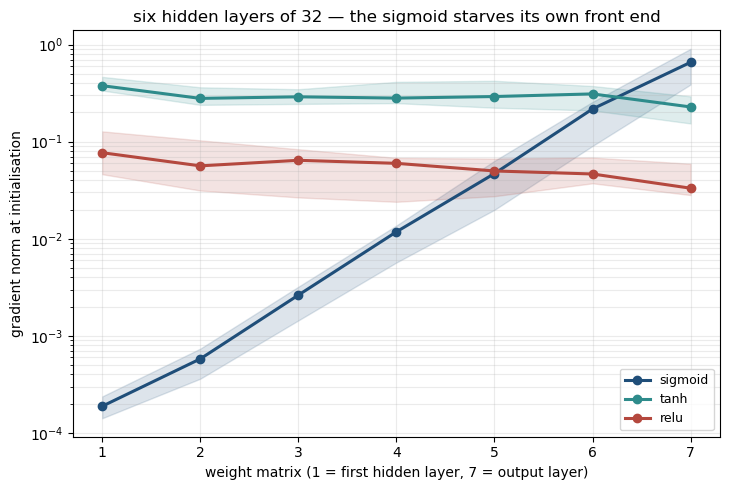

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))
positions = np.arange(1, norms["sigmoid"].shape[1] + 1)
for activation, colour in (("sigmoid", BLUE), ("tanh", TEAL), ("relu", RUST)):
    values = norms[activation]
    ax.plot(positions, np.median(values, axis=0), "o-", color=colour, lw=2.2,
            ms=6, label=activation)
    ax.fill_between(positions, values.min(axis=0), values.max(axis=0),
                    color=colour, alpha=.15)
ax.set_yscale("log")
ax.set_xlabel("weight matrix (1 = first hidden layer, 7 = output layer)")
ax.set_ylabel("gradient norm at initialisation")
ax.set_title("six hidden layers of 32 — the sigmoid starves its own front end")
ax.legend(fontsize=9)
ax.grid(alpha=.25, which="both")
fig.tight_layout()
fig.savefig(FIGURES / "vanishing_gradients.png", dpi=150)
plt.show()

Now vary the depth. If each sigmoid layer contributes a factor of about four,
the end-to-end ratio should grow like $4^{\text{depth}}$.

In [10]:
rows = []
for depth in (1, 2, 4, 6, 8):
    ratios = [kernel_gradient_norms(stack("sigmoid", depth=depth, seed=s))
              for s in range(5)]
    ratios = [r[-1] / r[0] for r in ratios]
    rows.append({"hidden layers": depth,
                 "median ratio": np.median(ratios),
                 "lowest": min(ratios), "highest": max(ratios),
                 "4 ** depth": 4.0 ** depth})
pd.DataFrame(rows).set_index("hidden layers").round(1)

,median ratio,lowest,highest,4 ** depth
hidden layers,,,,
1,2.3,1.9,2.3,4.0
2,9.5,7.4,13.4,16.0
4,169.6,131.4,196.5,256.0
6,3552.9,2740.8,4606.8,4096.0
8,46250.0,41174.1,76144.0,65536.0


## 6. What that costs when you actually train

A starved gradient is not an abstraction: the first layers barely move, so
the network spends its epochs training only its last few layers. Same data,
same depth, same optimiser — only the activation differs.

In [11]:
histories = {}
for activation, colour in (("sigmoid", BLUE), ("tanh", TEAL), ("relu", RUST)):
    model = stack(activation, depth=6, seed=0)
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    histories[activation] = model.fit(
        Xd_tr, yd_tr, validation_data=(Xd_va, yd_va), epochs=80,
        batch_size=32, verbose=0).history

for activation, history in histories.items():
    reached = next((i + 1 for i, a in enumerate(history["val_accuracy"])
                    if a > 0.85), None)
    print(f"{activation:8s} final validation accuracy "
          f"{history['val_accuracy'][-1]:.4f}   "
          f"epochs to reach 0.85: {reached if reached else 'never'}")

sigmoid  final validation accuracy 0.1000   epochs to reach 0.85: never
tanh     final validation accuracy 0.9750   epochs to reach 0.85: 3
relu     final validation accuracy 0.9611   epochs to reach 0.85: 9


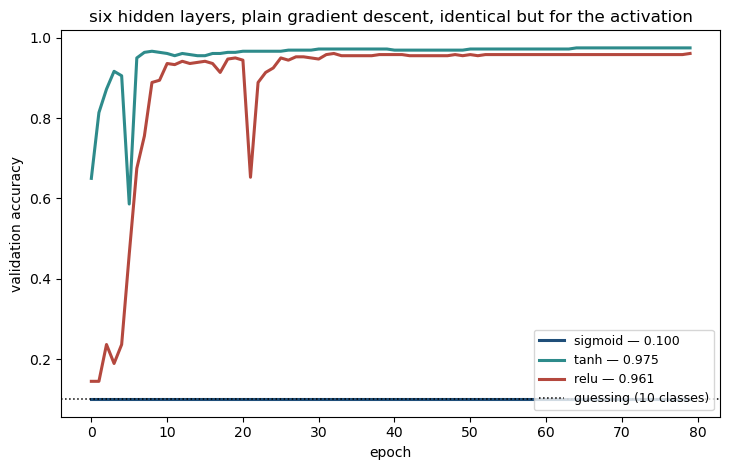

In [12]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for activation, colour in (("sigmoid", BLUE), ("tanh", TEAL), ("relu", RUST)):
    ax.plot(histories[activation]["val_accuracy"], color=colour, lw=2.2,
            label=f"{activation} — {histories[activation]['val_accuracy'][-1]:.3f}")
ax.axhline(0.1, color="k", lw=1.1, ls=":", label="guessing (10 classes)")
ax.set_xlabel("epoch")
ax.set_ylabel("validation accuracy")
ax.set_title("six hidden layers, plain gradient descent, identical but for the activation")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "deep_training_curves.png", dpi=150)
plt.show()

The sigmoid network never leaves chance — 0.10 on ten classes, after eighty
epochs, with a gradient that reaches its first layer some three thousand times
weaker than its last. Both alternatives are training within a handful of
epochs.

Note which one is fastest, because it is not the one the textbook slogan
predicts. **tanh gets there sooner than the ReLU here**, and that is
consistent with section 4 rather than a surprise: tanh is every bit as much a
squashing function as the sigmoid, and it is fine, because its derivative
peaks at 1. "Use ReLU" is good advice for reasons that mostly show up in much
deeper and much wider networks than this one — it is cheap, and it does not
saturate for large positive inputs. On six layers of 32 units, what separates
the winners from the loser is the ¼.

## 7. How big should the random weights be?

Notebook 01 showed that the weights cannot all start at zero. That leaves the
question of scale, and it is not a free parameter either. A layer computes
$z = \sum_i w_i a_i$ over $n$ inputs; if the weights are independent with
variance $\mathrm{Var}(w)$ then

$$\mathrm{Var}(z) = n \, \mathrm{Var}(w) \, \mathrm{Var}(a)$$

so the signal's variance is multiplied by $n\,\mathrm{Var}(w)$ at every layer.
Anything other than 1 compounds geometrically with depth. Setting
$\mathrm{Var}(w) = 1/n$ keeps it at 1, which is Glorot initialisation; ReLU
discards the negative half, so it needs $2/n$ — He initialisation, the one
notebook 01 used.

Watch what the alternatives do. The second column below is the giveaway: with
a bounded activation an over-large initialisation does not blow the signal up,
it **saturates** it — every unit pinned near $\pm 1$, where the derivative is
zero and nothing can learn.

In [13]:
def activation_spread(initializer, activation="tanh", depth=8, width=64, seed=0):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([keras.Input(shape=(64,))])
    for _ in range(depth):
        model.add(layers.Dense(width, activation=activation,
                               kernel_initializer=initializer))
    spreads, saturated, signal = [], [], tf.constant(Xd_tr[:256], dtype=tf.float32)
    for layer in model.layers:
        signal = layer(signal)
        spreads.append(float(tf.math.reduce_std(signal)))
        saturated.append(float(tf.reduce_mean(
            tf.cast(tf.abs(signal) > 0.99, tf.float32))))
    return spreads, saturated


schemes = {
    "N(0, 1) — far too large": keras.initializers.RandomNormal(stddev=1.0),
    "N(0, 0.01) — far too small": keras.initializers.RandomNormal(stddev=0.01),
    "Glorot (variance 1/n)": "glorot_normal",
}
measured = {name: activation_spread(init) for name, init in schemes.items()}
spreads = {name: value[0] for name, value in measured.items()}

print("fraction of tanh units saturated past |a| > 0.99, at layer 8:")
for name, (_, saturated) in measured.items():
    print(f"  {name:28s} {saturated[-1]:.3f}")
print()
pd.DataFrame(spreads, index=[f"layer {i}" for i in range(1, 9)]).round(4)

fraction of tanh units saturated past |a| > 0.99, at layer 8:
  N(0, 1) — far too large      0.730
  N(0, 0.01) — far too small   0.000
  Glorot (variance 1/n)        0.000



,"N(0, 1) — far too large","N(0, 0.01) — far too small",Glorot (variance 1/n)
layer 1,0.8858,0.0412,0.4063
layer 2,0.9432,0.0030,0.3705
layer 3,0.9433,0.0002,0.3224
layer 4,0.9463,0.0000,0.3066
layer 5,0.9466,0.0000,0.2772
layer 6,0.9473,0.0000,0.2512
layer 7,0.9472,0.0000,0.2180
layer 8,0.9472,0.0000,0.2102


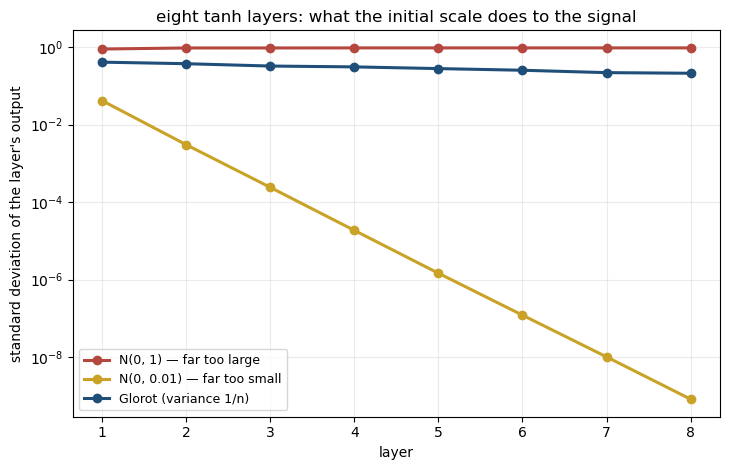

In [14]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for (name, values), colour in zip(spreads.items(), (RUST, GOLD, BLUE)):
    ax.plot(range(1, len(values) + 1), values, "o-", color=colour, lw=2.2,
            ms=6, label=name)
ax.set_yscale("log")
ax.set_xlabel("layer")
ax.set_ylabel("standard deviation of the layer's output")
ax.set_title("eight tanh layers: what the initial scale does to the signal")
ax.legend(fontsize=9)
ax.grid(alpha=.25, which="both")
fig.tight_layout()
fig.savefig(FIGURES / "init_scale.png", dpi=150)
plt.show()

Too small is the spectacular failure: the spread falls by an order of
magnitude per layer and is indistinguishable from zero by layer 4. Nothing
downstream can recover a signal that is no longer there.

Too large fails differently, and the printed saturation fraction is the
evidence. The spread does not explode, because tanh cannot exceed 1 — instead
73% of the units in the last layer are pinned past $|a| > 0.99$, where the
derivative is indistinguishable from zero. A saturated unit passes a signal
forward and nothing backward.

Glorot loses roughly half its spread over eight layers, against three orders
of magnitude for one alternative and near-total saturation for the other.
Halving is what "preserving the signal" looks like in practice, and it is the
same repair as the vanishing gradient seen from the other end: one is the
backward pass shrinking, the other the forward pass, and both are fixed by
making each layer roughly preserve variance.

## Summary

- Keras reproduces notebook 01's network in six lines, with the same
  parameter count and the same accuracy. Knowing what it does underneath is
  what makes its failures readable.
- Softmax generalises the sigmoid to $K$ classes, and pairs with categorical
  cross-entropy to give the same $\hat{y} - y$ gradient at the output.
- On digits, multiclass logistic regression is already within three points of
  the network: hidden layers pay when the answer depends on inputs *in
  combination*.
- **A sigmoid layer divides the gradient by about four**, because its
  derivative never exceeds ¼. Over six layers that compounds to roughly
  3,500 — but the end-to-end figure swings by a factor of two across seeds,
  and the per-layer factor is the part that is a property rather than a draw.
- A six-layer sigmoid network never leaves chance in eighty epochs. tanh and
  ReLU both train in a handful, and on this problem tanh is the quicker of the
  two — what matters is the ¼, not squashing as such.
- Initial weights need variance about $1/n$ — larger saturates, smaller fades.

Notebook 03 takes a network that works and asks what to do about the fact
that it fits the training data perfectly.